In [1]:
import numpy as np 
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import argparse
import networkx as nx
import argparse
import pickle
import pandas as pd

In [2]:
import random
alpha = 0.22   # 本地感染率
beta = 0.2   # 本地恢复率
gamma = 0.1  # 迁移/扩散率
# R0 = random.uniform(1.2, 2.2)

# beta = random.uniform(0.2, 0.33) # 恢复率
# alpha = beta * R0
# gamma = random.uniform(0.1, 0.3) # 迁移率

def simulation_metapop_sis(steps, P):
    """
    使用离散时间模型模拟集合种群SIS过程。
    """
    # --- 初始化 ---
    i = np.random.rand(n) * 0.05  # 初始感染比例
    s = 1 - i
    
    # 初始化轨迹记录
    i_trajr = i.reshape(1, -1)
    s_trajr = s.reshape(1, -1)

    # 预计算扩散项所需的部分
    P_out_strength = P.sum(axis=1) # D_out[i] = Σ_j P_ij
    
    # --- 模拟主循环 ---
    for t in range(1, steps):
        # --- 1. 反应步骤 (本地 SIS 动态) ---
        
        # a. 计算本地新增感染和恢复的个体比例
        #    这里我们使用一个更简单的本地感染项，以匹配微分方程的形式
        #    infect = s * (1 - np.exp(-alpha * i)) # 泊松模型
        #    或者更简单的均场近似：
        infect_local = alpha * s * i
        recover_local = beta * i
        
        # b. 计算反应后的中间状态
        i_after_reaction = i + infect_local - recover_local
        s_after_reaction = s - infect_local + recover_local

        # --- 2. 扩散步骤 (个体在节点间迁移) ---
        
        # a. 计算因扩散导致的感染者和易感者的净变化
        #    Δi_diffusion = gamma * (总流入 - 总流出)
        diffusion_net_change_i = gamma * (P.T @ i - P_out_strength * i)
        diffusion_net_change_s = gamma * (P.T @ s - P_out_strength * s)

        # b. 将扩散变化应用到反应后的状态上，得到最终的新状态
        i_new = i_after_reaction + diffusion_net_change_i
        s_new = s_after_reaction + diffusion_net_change_s
        
        # 更新状态变量 (使用旧的状态 i, s 进行扩散计算)
        i = i_new
        s = s_new
        
        # 保证比例在 [0, 1] 范围内
        i = np.clip(i, 0, 1)
        # 确保 s+i=1
        s = 1 - i
        
        # 记录轨迹
        i_trajr = np.concatenate([i_trajr, i.reshape(1, -1)], axis=0)
        s_trajr = np.concatenate([s_trajr, s.reshape(1, -1)], axis=0)
        
    # --- 格式化输出 ---
    i_trajr = np.expand_dims(i_trajr, axis=-1)

    s_trajr = np.expand_dims(s_trajr, axis=-1)
    
    # 最终形状为 [steps, n, 2]，通道0是I(i)，通道1是S(s)
    # trajectory = np.concatenate((i_trajr, s_trajr), axis=-1)
    
    return i_trajr

In [3]:
n = 223

edge_path = '/home/zjy/project/AnyEpi/data/simulate/edges.csv'
air_edge = pd.read_csv(edge_path)
# np.random.seed(exp_id)
# if args.graph in 'ER':
#     G = nx.erdos_renyi_graph(n,p,seed=exp_id)
# elif args.graph in 'NWS':
#     G = nx.newman_watts_strogatz_graph(n,k,p,seed=exp_id)
# elif args.graph in 'BA':
#     G = nx.barabasi_albert_graph(n,k,seed=exp_id)

source_indices = air_edge['Source']
target_indices = air_edge['Target']
edge_weights = air_edge['edge_weight']
G = nx.DiGraph()

for src, tgt, weight in zip(source_indices, target_indices, edge_weights):
    G.add_edge(src, tgt, weight=weight)
    
A = nx.to_numpy_array(G)

print(A.sum())
tr_num = 10
steps = 30
x_tr = np.zeros((tr_num,30,n,1))
for i in range(tr_num):
    print(f'Simulating training trajectory: {i+1:3d}/{tr_num:3d}')
    x_tr[i] = simulation_metapop_sis(steps, A)
    



222.99999999999977
Simulating training trajectory:   1/ 10
Simulating training trajectory:   2/ 10
Simulating training trajectory:   3/ 10
Simulating training trajectory:   4/ 10
Simulating training trajectory:   5/ 10
Simulating training trajectory:   6/ 10
Simulating training trajectory:   7/ 10
Simulating training trajectory:   8/ 10
Simulating training trajectory:   9/ 10
Simulating training trajectory:  10/ 10


正在绘制轨迹的热力图...


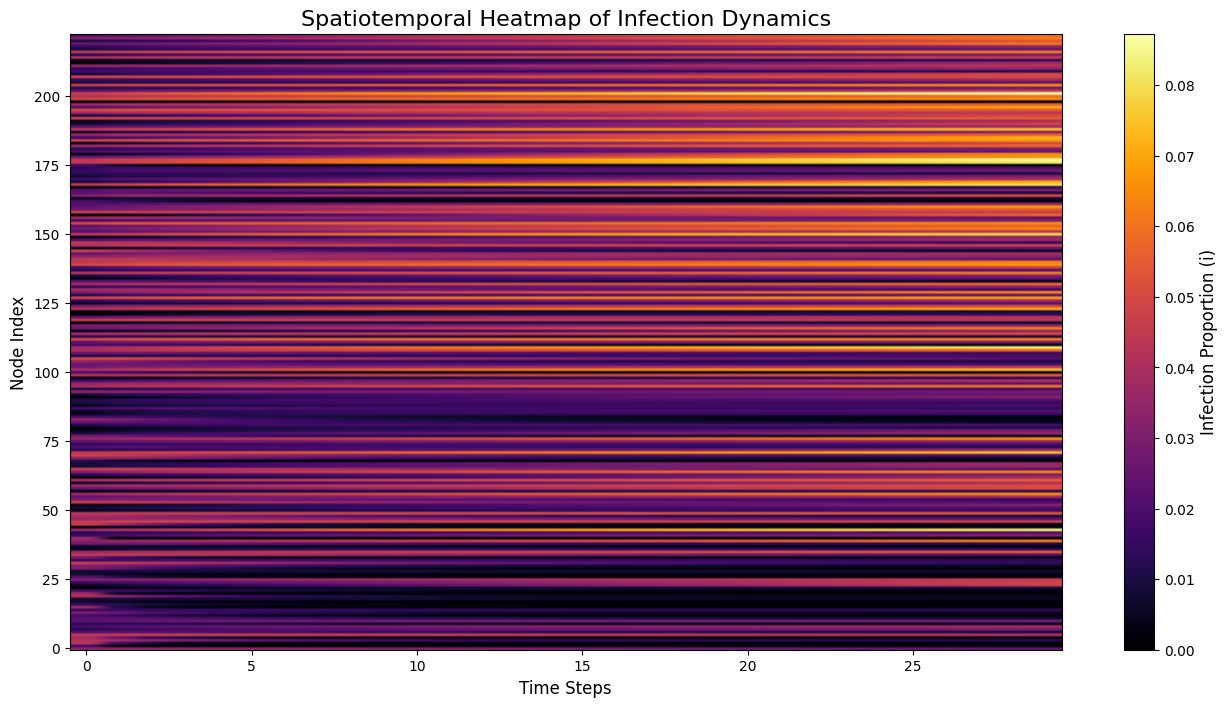

In [4]:
print("正在绘制轨迹的热力图...")
infection_trajectory = x_tr[0]
# 准备数据：我们需要一个 (n, steps) 的二维数组
# 首先，去掉最后一个维度 (特征维度)
data_for_heatmap = np.squeeze(infection_trajectory, axis=-1)
# 然后，转置数据，使得 Y 轴是节点，X 轴是时间
data_for_heatmap = data_for_heatmap.T  # 现在形状是 (n, steps)

# 创建图表
fig, ax = plt.subplots(figsize=(16, 8))

# 使用 imshow 绘制热力图
# cmap: colormap，选择一个合适的颜色映射，如 'viridis', 'plasma', 'inferno', 'Reds'
# aspect='auto': 允许图像的 x 和 y 轴有不同的缩放比例，让图像填满整个区域
# origin='lower': 将 y 轴的 0 点放在左下角，符合常规
im = ax.imshow(data_for_heatmap, cmap='inferno', aspect='auto', origin='lower')

# 添加一个颜色条 (colorbar) 来解释颜色代表的数值
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Infection Proportion (i)', fontsize=12)

# 设置图表的标题和坐标轴标签
ax.set_title('Spatiotemporal Heatmap of Infection Dynamics', fontsize=16)
ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Node Index', fontsize=12)

plt.show()